# Z3-Python 02 — Sudoku comme probleme de satisfaction de contraintes

**Navigation** : [<< Z3-Python-01 Introduction](Z3-Python-01-Introduction.ipynb) | [Index](README.md)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Modeliser** le Sudoku comme un probleme de satisfaction de contraintes (CSP) en z3-py
2. **Formaliser** les regles (lignes, colonnes, blocs 3x3) sous forme de contraintes `Distinct`
3. **Visualiser** une grille et sa solution avec matplotlib
4. **Confronter** l'approche declarative (Z3) a l'approche imperative (backtracking)

### Prerequis
- Avoir suivi [Z3-Python-01 Introduction](Z3-Python-01-Introduction.ipynb)
- Notions de Sudoku (regles du jeu)

### Duree estimee : ~25 min

---

Le [notebook precedent](Z3-Python-01-Introduction.ipynb) a introduit le solveur Z3. Ici, nous l'appliquons a un probleme NP-complet emblematique : le **Sudoku**. L'approche contraste avec la serie [Sudoku par backtracking](../../../Sudoku/Sudoku-1-Backtracking-Python.ipynb) : au lieu de programmer l'algorithme de recherche, nous **enonc ons les regles** et laissons le solveur deduire la solution.

In [1]:
# Imports
from z3 import *
import matplotlib.pyplot as plt
from typing import List, Optional

print("Imports OK : z3, matplotlib")

Imports OK : z3, matplotlib


## 1. Grilles de Sudoku

Nous codons une grille 9x9 comme une liste de listes d'entiers, ou `0` represente une case vide. Nous partons de deux puzzles : un puzzle **facile** (beaucoup d'indices) et un puzzle **intermediaire**.

In [2]:
# Deux grilles de Sudoku (0 = case vide).
# Puzzle facile : 35 indices donnes.
puzzle_facile = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9],
]

# Puzzle intermediaire : 30 indices donnes.
puzzle_intermediaire = [
    [0, 0, 0, 2, 6, 0, 7, 0, 1],
    [6, 8, 0, 0, 7, 0, 0, 9, 0],
    [1, 9, 0, 0, 0, 4, 5, 0, 0],
    [8, 2, 0, 1, 0, 0, 0, 4, 0],
    [0, 0, 4, 6, 0, 2, 9, 0, 0],
    [0, 5, 0, 0, 0, 3, 0, 2, 8],
    [0, 0, 9, 3, 0, 0, 0, 7, 4],
    [0, 4, 0, 0, 5, 0, 0, 3, 6],
    [7, 0, 3, 0, 1, 8, 0, 0, 0],
]

def compter_indices(grille: List[List[int]]) -> int:
    """Compte le nombre de cases non vides (indices donnes)."""
    return sum(1 for r in range(9) for c in range(9) if grille[r][c] != 0)

print(f"Puzzle facile : {compter_indices(puzzle_facile)} indices donnes")
print(f"Puzzle intermediaire : {compter_indices(puzzle_intermediaire)} indices donnes")

Puzzle facile : 30 indices donnes
Puzzle intermediaire : 36 indices donnes


## 2. Modelisation declarative du Sudoku

La modelisation en Z3 se resume a **trois familles de contraintes** :

1. **Domaine** : chaque case contient un entier entre 1 et 9.
2. **Indices** : les cases pre-remplies conservent leur valeur.
3. **Unicite** : chaque ligne, chaque colonne et chaque bloc 3x3 contient des valeurs **deux a deux distinctes** (contrainte `Distinct`).

C'est tout. Aucune boucle de recherche, aucun backtracking explicite : on decrit **le quoi**, pas le comment.

In [3]:
def resoudre_sudoku(grille: List[List[int]]) -> Optional[List[List[int]]]:
    """Resout une grille de Sudoku avec Z3 de facon declarative.

    Args:
        grille: Grille 9x9, 0 = case vide.

    Returns:
        Grille 9x9 resolue, ou None si insatisfiable.
    """
    s = Solver()
    # Variables : 81 entiers c_{r}_{c}
    cellules = [[Int(f'c_{r}_{c}') for c in range(9)] for r in range(9)]

    # 1. Domaine : 1 <= cellule <= 9
    for r in range(9):
        for c in range(9):
            s.add(cellules[r][c] >= 1, cellules[r][c] <= 9)

    # 2. Indices : figer les cases pre-remplies
    for r in range(9):
        for c in range(9):
            if grille[r][c] != 0:
                s.add(cellules[r][c] == grille[r][c])

    # 3a. Unicite par ligne
    for r in range(9):
        s.add(Distinct([cellules[r][c] for c in range(9)]))
    # 3b. Unicite par colonne
    for c in range(9):
        s.add(Distinct([cellules[r][c] for r in range(9)]))
    # 3c. Unicite par bloc 3x3
    for br in range(3):
        for bc in range(3):
            bloc = [cellules[3*br + i][3*bc + j] for i in range(3) for j in range(3)]
            s.add(Distinct(bloc))

    if s.check() == sat:
        m = s.model()
        return [[m[cellules[r][c]].as_long() for c in range(9)] for r in range(9)]
    return None

# Resolution du puzzle facile
solution_facile = resoudre_sudoku(puzzle_facile)
print("Puzzle facile :", "resolu" if solution_facile else "insatisfiable")
for ligne in solution_facile:
    print(ligne)

Puzzle facile : resolu
[5, 3, 4, 6, 7, 8, 9, 1, 2]
[6, 7, 2, 1, 9, 5, 3, 4, 8]
[1, 9, 8, 3, 4, 2, 5, 6, 7]
[8, 5, 9, 7, 6, 1, 4, 2, 3]
[4, 2, 6, 8, 5, 3, 7, 9, 1]
[7, 1, 3, 9, 2, 4, 8, 5, 6]
[9, 6, 1, 5, 3, 7, 2, 8, 4]
[2, 8, 7, 4, 1, 9, 6, 3, 5]
[3, 4, 5, 2, 8, 6, 1, 7, 9]


### Interpretation : la puissance de la declaration

**Sortie obtenue** : Z3 resout le puzzle instantanement et affiche la grille complete.

| Famille de contraintes | Nombre | Role |
|------------------------|--------|------|
| Domaine (1-9) | 81 | Bornes des variables |
| Indices figes | ~35 | Enonce du puzzle |
| `Distinct` ligne | 9 | Une seule occurrence par ligne |
| `Distinct` colonne | 9 | Une seule occurrence par colonne |
| `Distinct` bloc | 9 | Une seule occurrence par bloc 3x3 |

**Points cles** :
1. **Aucun algorithme de recherche ecrit a la main** : Z3 gere lui-meme l'exploration.
2. La contrainte `Distinct([...])` exprime naturellement « tous differents ».
3. Le meme code resout n'importe quel puzzle, du facile a l'expert : seules les donnees changent.

## 3. Visualisation : donne en noir, resolu en bleu

Pour distinguer les indices fournis par l'enonce des valeurs deduites par le solveur, nous reprenons le style de visualisation de la [serie Sudoku par backtracking](../../../Sudoku/Sudoku-1-Backtracking-Python.ipynb). Les valeurs **initiales** s'affichent en noir, les valeurs **ajoutees** par Z3 en bleu.

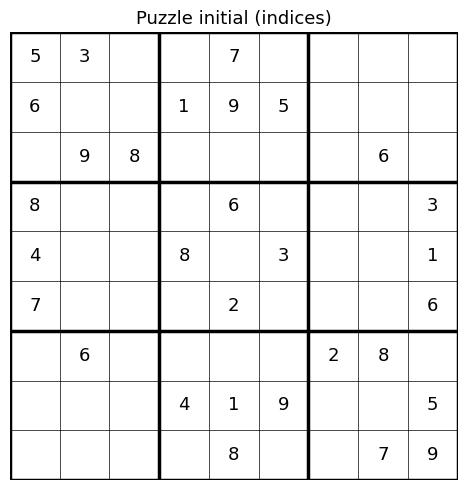

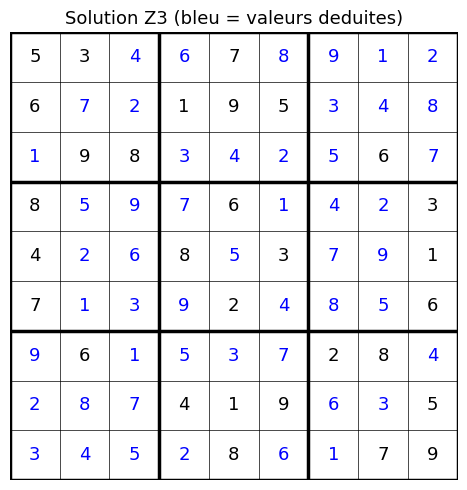

In [4]:
def plot_sudoku(grid: List[List[int]], title: str = "Sudoku",
                initial: Optional[List[List[int]]] = None):
    """Affiche une grille 9x9 avec matplotlib.

    Args:
        grid: Grille 9x9 a afficher.
        title: Titre du graphique.
        initial: Grille initiale (0 = vide). Si fournie, les cases ou
                 initial[r][c] == 0 (resolues par le solveur) sont affichees
                 en bleu, les indices donnes en noir.
    """
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13)

    # Lignes : epaisses sur les separateurs de blocs 3x3
    for i in range(10):
        lw = 2.5 if i % 3 == 0 else 0.5
        ax.axhline(i, color='black', linewidth=lw)
        ax.axvline(i, color='black', linewidth=lw)

    # Valeurs
    for r in range(9):
        for c in range(9):
            val = grid[r][c]
            if val != 0:
                if initial is not None and initial[r][c] == 0:
                    color = 'blue'   # valeur ajoutee par le solveur
                else:
                    color = 'black'  # indice donne
                ax.text(c + 0.5, 8.5 - r, str(val),
                        ha='center', va='center', fontsize=13, color=color)

    plt.tight_layout()
    plt.show()

# Puzzle initial : tout en noir (indices)
plot_sudoku(puzzle_facile, "Puzzle initial (indices)")

# Solution : indices en noir, valeurs deduites en bleu
plot_sudoku(solution_facile, "Solution Z3 (bleu = valeurs deduites)", puzzle_facile)

### Interpretation : declaratif vs imperatif

La visualisation met en evidence la difference fondamentale d'approche.

| Aspect | Backtracking (serie Sudoku) | Z3 declaratif (ce notebook) |
|--------|------------------------------|------------------------------|
| **Ce qu'on ecrit** | L'algorithme de recherche (DFS, retour-arriere) | Les regles du jeu (`Distinct`, domaines) |
| **Strategie** | MRV, elagage, heuristiques codees a la main | Deleguee au solveur |
| **Adaptation** | Reecrire l'algorithme pour chaque variante | Ajouter une contrainte |
| **Lecture du code** | Comment on explore | Ce qu'on veut obtenir |

**Points cles** :
1. En bleu apparaissent les valeurs que Z3 a deduites : aucun retour-arriere manuel.
2. Ajouter une regle (anti-diagonale, variante X-Sudoku) se resume a **une contrainte supplementaire**.
3. Le cout : on perd le controle fin sur la strategie de recherche (mais Z3 est tres optimise).

> **Note technique** : Z3 combine en interne resolution SAT, propagation et theories arithmetiques. Sur le Sudoku (instance petite), la resolution est quasi instantanee (< 10 ms).

## Exercice 1 : Variante anti-diagonale

### Enonce

Certains Sudokus imposent une regle supplementaire : l'**anti-diagonale** (du coin haut-droit au coin bas-gauche) doit elle aussi contenir les chiffres 1 a 9 sans repetition.

Modifiez la fonction de resolution pour ajouter cette contrainte et resoudre le puzzle facile.

### Indices

- L'anti-diagonale correspond aux cases `(r, 8 - r)` pour `r` de 0 a 8.
- Ajoutez un `Distinct([cellules[r][8 - r] for r in range(9)])`.
- Attention : selon le puzzle, cette contrainte supplementaire peut le rendre `unsat`.

In [5]:
# EXERCICE 1 : Resoudre le Sudoku avec une contrainte d'anti-diagonale.

def resoudre_sudoku_anti_diagonale(grille: List[List[int]]) -> Optional[List[List[int]]]:
    """Resout le Sudoku avec la regle supplementaire :
    l'anti-diagonale (cases (r, 8-r)) contient 1 a 9 sans repetition.

    # Indice : reprenez resoudre_sudoku et ajoutez la contrainte d'anti-diagonale.
    # Etape 1 : recopier la modelisation de base (domaine, indices, lignes, colonnes, blocs)
    # Etape 2 : ajouter Distinct([cellules[r][8 - r] for r in range(9)])
    # Etape 3 : verifier sat et retourner la solution
    """
    # TODO etudiant : implémentez la variante anti-diagonale
    return None  # TODO etudiant : remplacer par la solution

sol_ad = resoudre_sudoku_anti_diagonale(puzzle_facile)
print("Solution anti-diagonale :", "trouvée" if sol_ad else "insatisfiable")

Solution anti-diagonale : insatisfiable


## Exercice 2 : Resoudre le puzzle intermediaire

### Enonce

Utilisez la fonction `resoudre_sudoku` pour resoudre `puzzle_intermediaire`, puis visualisez la solution avec `plot_sudoku`. Verifiez visuellement la coherence.

### Indices

- Appelez `resoudre_sudoku(puzzle_intermediaire)`.
- Affichez le puzzle initial puis la solution avec `plot_sudoku(..., initial=puzzle_intermediaire)`.

In [6]:
# EXERCICE 2 : Resoudre et visualiser le puzzle intermediaire.

def resoudre_et_visualiser(grille: List[List[int]]):
    """Resout la grille puis affiche le puzzle et sa solution.

    # Indice : utilisez resoudre_sudoku puis plot_sudoku.
    # Etape 1 : appeler resoudre_sudoku(grille)
    # Etape 2 : afficher plot_sudoku(grille, "Puzzle")
    # Etape 3 : afficher plot_sudoku(solution, "Solution", initial=grille)
    """
    # TODO etudiant : résolvez et visualisez
    pass

resultat_ex2 = resoudre_et_visualiser(puzzle_intermediaire)
print("Exercice 2 :", "résolu et visualisé" if resultat_ex2 is not None else "à compléter (la fonction ne fait rien)")

Exercice 2 : à compléter (la fonction ne fait rien)


## Exercice 3 : Detecter les solutions multiples

### Enonce

Un puzzle de Sudoku bien forme possede une **solution unique**. Une grille trop peu remplie peut en admettre plusieurs. Ecrivez une fonction qui compte le nombre de solutions (borne a 2) en ajoutant une **clause bloquante** apres chaque solution trouvee.

### Indices

- Apres avoir trouve un modele, construisez une clause qui interdit exactement cette solution : `Or([cellules[r][c] != val pour toutes les cases])`.
- Ajoutez cette clause avec `s.add(...)` et rappelez `s.check()`.
- Arretez des que 2 solutions sont trouvees ou que `check()` renvoie `unsat`.

In [7]:
# EXERCICE 3 : Compter le nombre de solutions (jusqu'a 2).

def compter_solutions(grille: List[List[int]], max_solutions: int = 2) -> int:
    """Compte le nombre de solutions, borne a max_solutions.

    # Indice : apres chaque modele, bloquez cette solution avec une clause
    #           Or([cellules[r][c] != valeur_trouvee, ...]) puis re-iterz.
    # Etape 1 : modeliser le Sudoku (comme dans resoudre_sudoku)
    # Etape 2 : boucler sur s.check() == sat, extraire le modele, incrementer
    # Etape 3 : ajouter la clause bloquante et continuer
    """
    # TODO etudiant : implémentez le comptage de solutions
    return 0  # TODO etudiant : remplacer par le nombre de solutions trouvées

# Test : le puzzle facile bien forme doit avoir exactement 1 solution.
nb = compter_solutions(puzzle_facile)
print(f"Nombre de solutions du puzzle facile : {nb} (attendu : 1)")

Nombre de solutions du puzzle facile : 0 (attendu : 1)


## Recapitulatif

Ce notebook a montre comment **trois familles de contraintes** (domaine, indices, unicite) suffisent a modeliser et resoudre le Sudoku de facon entierement declarative.

| Element | Approche Z3 | Benefice |
|---------|-------------|----------|
| Modelisation | `Int` + `Distinct` | Code court, lisible |
| Resolution | `s.check()` automatique | Aucun algorithme a ecrire |
| Variante (anti-diagonale) | Une contrainte de plus | Evolutivite immediate |
| Visualisation | matplotlib (noir = donne, bleu = resolu) | Verification visuelle |

La force du paradigme declaratif est l'**evolutivite** : chaque nouvelle regle se traduit par une contrainte, sans reecrire la logique de recherche. Pour aller plus loin, consultez la [documentation z3-py](https://microsoft.github.io/z3guide/) et la serie [Sudoku par approches multiples](../../../Sudoku/README.md) qui compare Z3 a dix autres techniques algorithmiques.